# Engagement–Outcome Validation

The BI report shows engagement (clicks) varies sharply by module — up to a 20x
spread between the highest and lowest. That's suggestive, not proof: it shows
engagement differs, not that engagement *predicts* outcome. This notebook tests
that relationship directly with a proper statistical test rather than a visual
impression from a bar chart.

**Question:** does student engagement (total clicks) predict withdrawal?

Connects to Gold via the SQL analytics endpoint, using device-code Entra ID auth
(credentials never hardcoded — see `.env.example` for required variables).

In [ ]:
%pip install azure-identity

In [2]:
import pyodbc
import pandas as pd
from sqlalchemy import create_engine
import urllib
import struct
import os
from dotenv import load_dotenv
from azure.identity import DeviceCodeCredential
from scipy import stats

## Connect to Gold via device-code authentication

`ActiveDirectoryInteractive` failed silently on this machine (a known ODBC
Driver 18 issue tied to the embedded browser component). Getting the access
token directly via `azure-identity` and passing it to `pyodbc` sidesteps that
driver-level auth path entirely.

In [3]:
load_dotenv()
server = os.getenv("FABRIC_SQL_SERVER")
database = os.getenv("FABRIC_SQL_DATABASE")

# Get an access token via device code flow (prints a URL + code to sign in with)
credential = DeviceCodeCredential()
token = credential.get_token("https://database.windows.net/.default")

# Encode the token the way the ODBC driver expects it
token_bytes = token.token.encode("utf-16-le")
token_struct = struct.pack(f'<I{len(token_bytes)}s', len(token_bytes), token_bytes)
SQL_COPT_SS_ACCESS_TOKEN = 1256

connection_string = (
    f"Driver={{ODBC Driver 18 for SQL Server}};"
    f"Server={server},1433;"
    f"Database={database};"
    f"Encrypt=yes;"
    f"TrustServerCertificate=no;"
)

params = urllib.parse.quote_plus(connection_string)
engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}",
    connect_args={'attrs_before': {SQL_COPT_SS_ACCESS_TOKEN: token_struct}}
)

To sign in, use a web browser to open the page https://login.microsoft.com/device and enter the code FMK4BTNJX to authenticate.


## Pull student-level clicks and outcome

`fact_vle` is aggregated to student+module+day grain; `fact_registration` is
one row per student+module. Aggregating clicks to student+module *before*
joining avoids fanning out the join — the same composite-key discipline used
throughout Gold.

In [5]:
query = """
WITH student_clicks AS (
    SELECT student_sk, module_sk, SUM(total_clicks) AS total_clicks
    FROM fact_vle
    GROUP BY student_sk, module_sk
)
SELECT
    r.student_sk,
    r.module_sk,
    r.is_withdrawn,
    ISNULL(c.total_clicks, 0) AS total_clicks
FROM fact_registration r
LEFT JOIN student_clicks c
    ON r.student_sk = c.student_sk AND r.module_sk = c.module_sk
"""

df = pd.read_sql(query, engine)
assert len(df) == 32593, f"Row count mismatch: expected 32,593, got {len(df)}"
print(f"Rows pulled: {len(df)} matches fact_registration exactly")

Rows pulled: 32593 matches fact_registration exactly


## Sanity-check the data before testing anything

Confirm the outcome variable is genuinely binary and clicks aren't dominated by outliers/nulls before running a correlation on them blind.

In [6]:
print(df['is_withdrawn'].value_counts())
print()
print(df['total_clicks'].describe())

is_withdrawn
False    22521
True     10072
Name: count, dtype: int64

count    32593.000000
mean      1215.141257
std       1692.604449
min          0.000000
25%        142.000000
50%        602.000000
75%       1585.000000
max      24139.000000
Name: total_clicks, dtype: float64


## Test: does engagement predict withdrawal?

Point-biserial correlation — the correct test for a continuous variable (clicks) against a binary outcome (withdrawn/not). Two things determine whether this is meaningful, not just whether it's "real":

- **Sign**: if engagement genuinely helps outcomes, expect a *negative* correlation (more clicks → less likely to withdraw). A positive result isn't necessarily wrong, but it's worth checking the coding direction of `is_withdrawn` before concluding anything.
  
- **Magnitude, not just significance**: with n=32,593, even a very small correlation will be statistically significant. The coefficient's size is what determines whether the relationship is meaningful, not the p-value alone.

In [7]:
correlation, p_value = stats.pointbiserialr(df['is_withdrawn'], df['total_clicks'])

print(f"Point-biserial correlation: {correlation:.4f}")
print(f"P-value: {p_value:.6f}")

Point-biserial correlation: -0.3557
P-value: 0.000000


## Result: a real, moderate relationship — with an important caveat

Point-biserial correlation between total clicks and withdrawal: **r = -0.356, p < 0.000001** (n = 32,593). The negative sign confirms the expected direction: more engagement associates with lower withdrawal. A correlation of this magnitude is generally considered a moderate effect, not a statistical artifact of the large sample size.

**What this does not prove:** correlation is not causation. Highly-engaged students may simply be more academically committed generally — clicking more because they're already less likely to withdraw, not the other way around. This analysis cannot distinguish "engagement causes retention" from "committed students engage more." A causal claim would require controlling for prior academic history and module, at minimum — noted as a next step in the project's Technical Roadmap.

## Group comparison: clicks by outcome

The correlation coefficient is abstract on its own. This shows the same relationship as an actual distribution comparison, and reports the median (not mean) explicitly, since clicks are heavily right-skewed — a few very high-engagement students would distort a mean-based comparison.

In [8]:
medians = df.groupby('is_withdrawn')['total_clicks'].median()
print(f"Median clicks — stayed: {medians[False]:.0f}")
print(f"Median clicks — withdrawn: {medians[True]:.0f}")

Median clicks — stayed: 994
Median clicks — withdrawn: 90


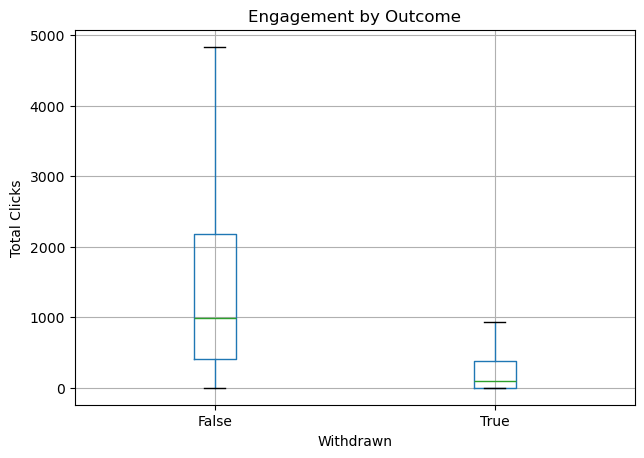

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
df.boxplot(column='total_clicks', by='is_withdrawn', ax=ax, showfliers=False)

ax.set_xlabel('Withdrawn')
ax.set_ylabel('Total Clicks')
ax.set_title('Engagement by Outcome')
plt.suptitle('')  # removes the default pandas-added title
plt.savefig('assets/engagement_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

## Result: a real, substantial relationship — with an important caveat

Point-biserial correlation between total clicks and withdrawal: **r = -0.356, p < 0.000001** (n = 32,593), confirming the expected direction: more engagement associates with lower withdrawal.

The group comparison makes the size of this gap concrete: students who stayed enrolled clicked a median of **994** times; students who withdrew clicked a median of **90** — an 11x difference, with minimal overlap between the two distributions.

![Engagement by outcome](assets/engagement_by_outcome.png)

**What this does not prove:** correlation is not causation. Highly-engaged students may simply be more academically committed generally — clicking more because they're already less likely to withdraw, not the other way around. This analysis cannot distinguish "engagement causes retention" from "committed students engage more." A causal claim would require controlling for prior academic history and module, at minimum — noted as a next step in the project's Technical Roadmap.